# Neural Network Training and Visualization
## MNIST Digit Recognition with Backpropagation

This notebook demonstrates training a neural network from scratch on the MNIST dataset and visualizing the training process and predictions.

In [14]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import random
import time
import seaborn as sns

# Import custom modules
import mnist_loader
import neuralnet

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load and Prepare MNIST Data

In [9]:
# Load MNIST data (wrapped for neural network)
random.seed(42)
np.random.seed(42)

# Use wrapper that returns training/validation/test as tuples suitable for the network
training_data, validation_data, test_data = mnist_loader.load_data_wrapper()
training_data = list(training_data)
validation_data = list(validation_data)
test_data = list(test_data)

print(f"Dataset loaded successfully!")
print(f"  Training samples: {len(training_data)}")
print(f"  Validation samples: {len(validation_data)}")
print(f"  Test samples: {len(test_data)}")
print(f"  Input shape: {training_data[0][0].shape}")
print(f"  Output shape: {training_data[0][1].shape}")

Dataset loaded successfully!
  Training samples: 50000
  Validation samples: 10000
  Test samples: 10000
  Input shape: (784, 1)
  Output shape: (10, 1)


## 2. Visualize Sample Training Data

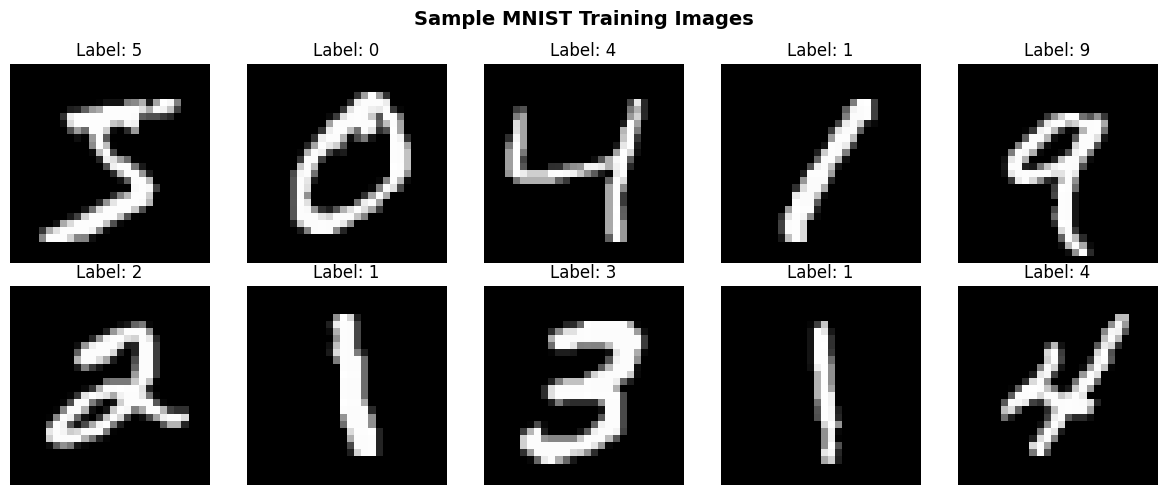

In [10]:
# Visualize sample training images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample MNIST Training Images', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    x, y = training_data[i]
    image = x.reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Label: {np.argmax(y)}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Initialize the Neural Network

Configure network architecture and training parameters:

In [16]:
# Network configuration
NETWORK_SIZES = [784, 64, 32, 10]  # Input, Hidden1, Hidden2, Output layers
EPOCHS = 10
MINI_BATCH_SIZE = 10
LEARNING_RATE = 3.0  # eta

# Initialize the neural network
print(f"Initializing neural network with architecture: {NETWORK_SIZES}")
net = neuralnet.Network(NETWORK_SIZES)
print(f"Number of layers: {net.nlayers}")
print(f"Parameters:")
print(f"  - Epochs: {EPOCHS}")
print(f"  - Mini-batch size: {MINI_BATCH_SIZE}")
print(f"  - Learning rate (eta): {LEARNING_RATE}")

Initializing neural network with architecture: [784, 64, 32, 10]
Number of layers: 4
Parameters:
  - Epochs: 10
  - Mini-batch size: 10
  - Learning rate (eta): 3.0


## 4. Train the Neural Network

This section trains the network using mini-batch stochastic gradient descent (SGD) with backpropagation:

In [17]:
# Train using the network's SGD method
print("\n" + "="*60)
print("Starting Training using neuralnet.SGD...")
print("="*60 + "\n")

# Use network's SGD implementation
net.SGD(training_data, EPOCHS, MINI_BATCH_SIZE, LEARNING_RATE, test_data=test_data)


Starting Training using neuralnet.SGD...

Epoch 0: 9138 / 10000, took 7.33 seconds
Epoch 1: 9259 / 10000, took 5.90 seconds
Epoch 2: 9374 / 10000, took 5.83 seconds
Epoch 3: 9449 / 10000, took 6.04 seconds
Epoch 4: 9488 / 10000, took 5.85 seconds
Epoch 5: 9438 / 10000, took 8.73 seconds
Epoch 6: 9535 / 10000, took 9.93 seconds
Epoch 7: 9523 / 10000, took 10.57 seconds
Epoch 8: 9563 / 10000, took 10.52 seconds
Epoch 9: 9533 / 10000, took 10.05 seconds


## 6. Evaluate Model Performance

Generate predictions on test data and display detailed metrics:

In [19]:
# Generate predictions on test data
print("Generating predictions on test data...")
predictions = []
true_labels = []

for x, y in test_data:
    output = net.feedforward(x)
    pred = int(np.argmax(output))
    if isinstance(y, np.ndarray):
        true = int(np.argmax(y))
    else:
        true = int(y)
    predictions.append(pred)
    true_labels.append(true)

predictions = np.array(predictions)
true_labels = np.array(true_labels)

# Calculate accuracy
test_accuracy = np.mean(predictions == true_labels)
print(f"\nTest Set Accuracy: {100 * test_accuracy:.2f}%")
print(f"Correct predictions: {np.sum(predictions == true_labels)}/{len(test_data)}")
print(f"Incorrect predictions: {np.sum(predictions != true_labels)}/{len(test_data)}")

Generating predictions on test data...

Test Set Accuracy: 95.33%
Correct predictions: 9533/10000
Incorrect predictions: 467/10000


### Confusion Matrix

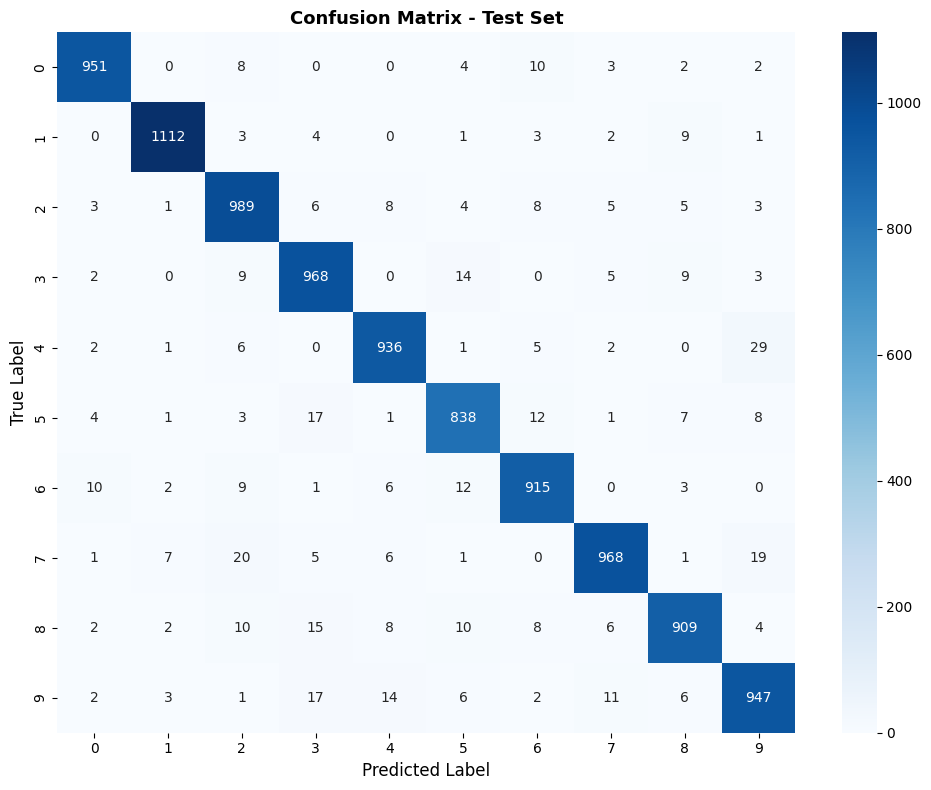

In [21]:
# Generate confusion matrix
try:
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(true_labels, predictions)
    
    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
                xticklabels=range(10), yticklabels=range(10))
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title('Confusion Matrix - Test Set', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
except ImportError:
    print("scikit-learn not available. Skipping confusion matrix.")

### Per-Digit Accuracy

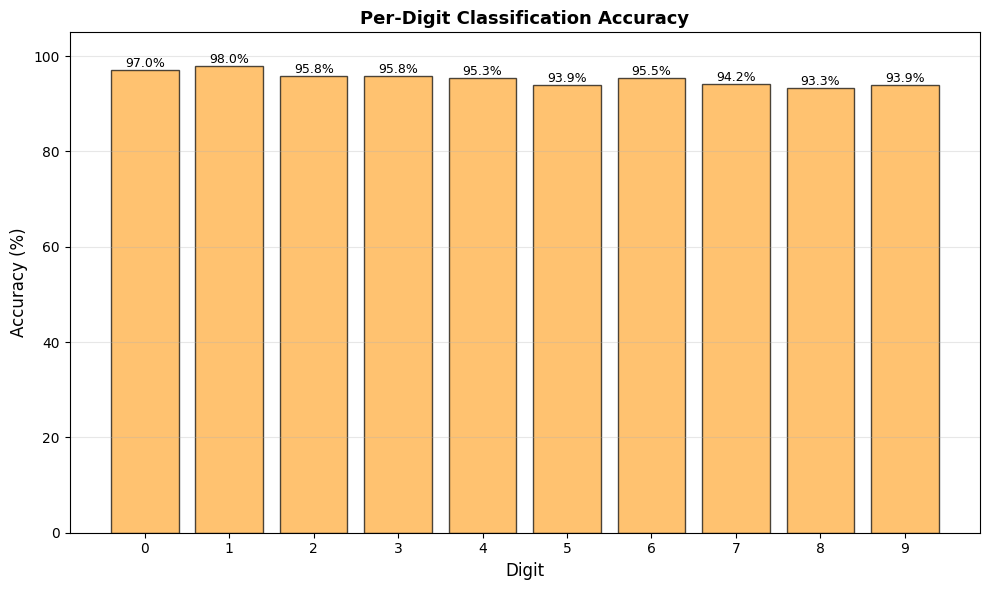

In [22]:
# Per-digit accuracy
per_digit_accuracy = []
for digit in range(10):
    mask = true_labels == digit
    if np.sum(mask) > 0:
        digit_accuracy = np.mean(predictions[mask] == true_labels[mask])
        per_digit_accuracy.append(digit_accuracy)
    else:
        per_digit_accuracy.append(0)

# Plot per-digit accuracy
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(10), [100*acc for acc in per_digit_accuracy], color='#FFA933', alpha=0.7, edgecolor='black')
ax.set_xlabel('Digit', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-Digit Classification Accuracy', fontsize=13, fontweight='bold')
ax.set_xticks(range(10))
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{per_digit_accuracy[i]*100:.1f}%',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Visualize Predictions

Display sample predictions alongside confidence scores:

Visualizing correct predictions...


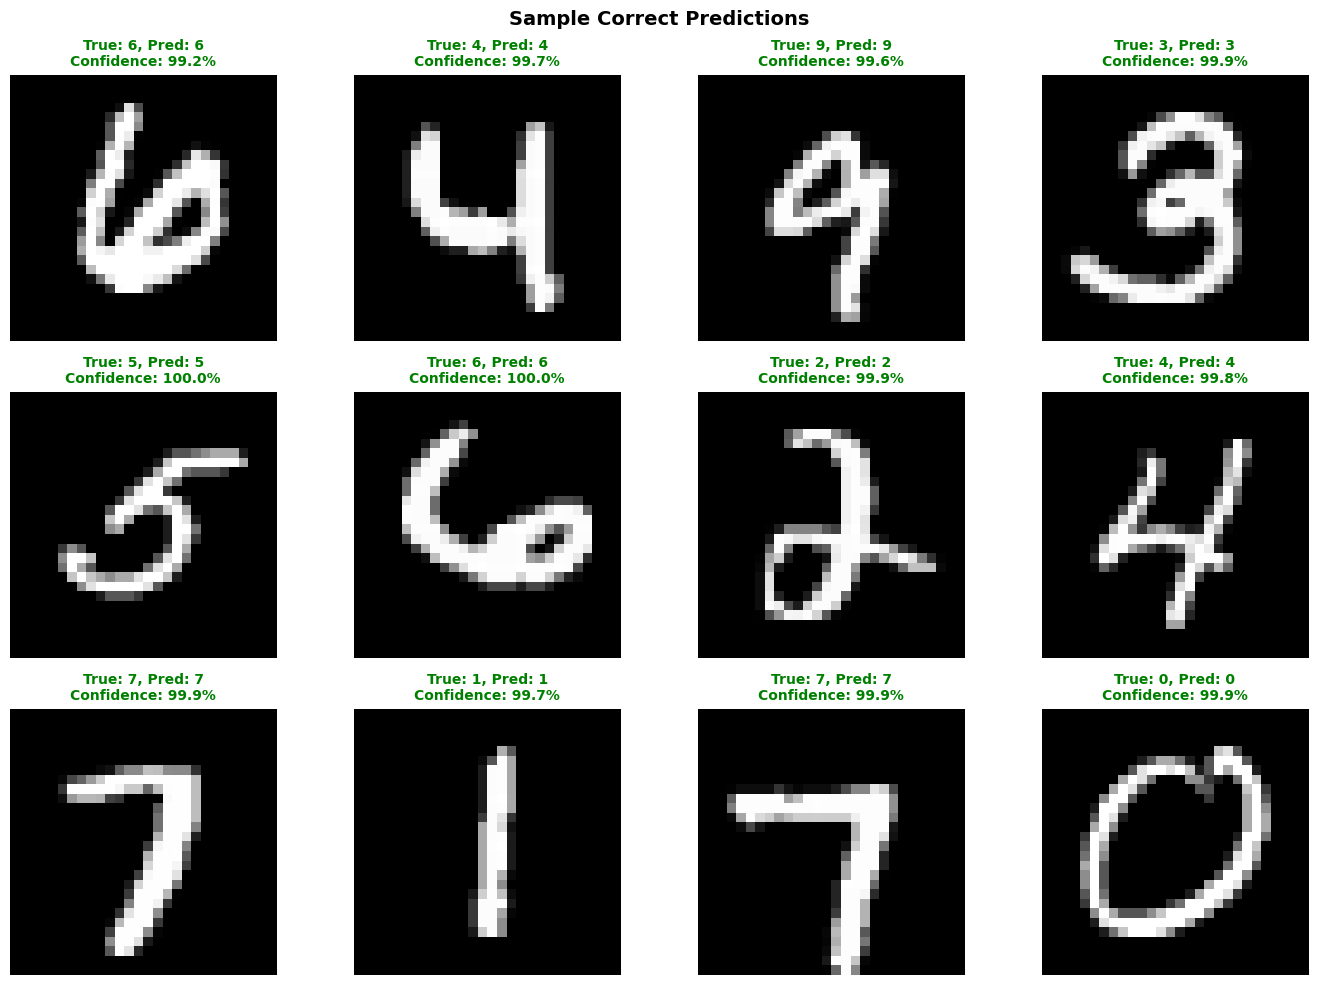

In [23]:
# Visualize correct predictions
print("Visualizing correct predictions...")
correct_indices = np.where(predictions == true_labels)[0]
correct_sample_indices = np.random.choice(correct_indices, min(12, len(correct_indices)), replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Sample Correct Predictions', fontsize=14, fontweight='bold')

for idx, img_idx in enumerate(correct_sample_indices):
    ax = axes[idx // 4, idx % 4]
    x, y = test_data[img_idx]
    image = x.reshape(28, 28)
    
    # Get network output for confidence
    output = net.feedforward(x)
    confidence = np.max(output)
    
    ax.imshow(image, cmap='gray')
    ax.set_title(f'True: {true_labels[img_idx]}, Pred: {predictions[img_idx]}\nConfidence: {confidence*100:.1f}%', 
                 fontsize=10, color='green', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

Visualizing incorrect predictions...


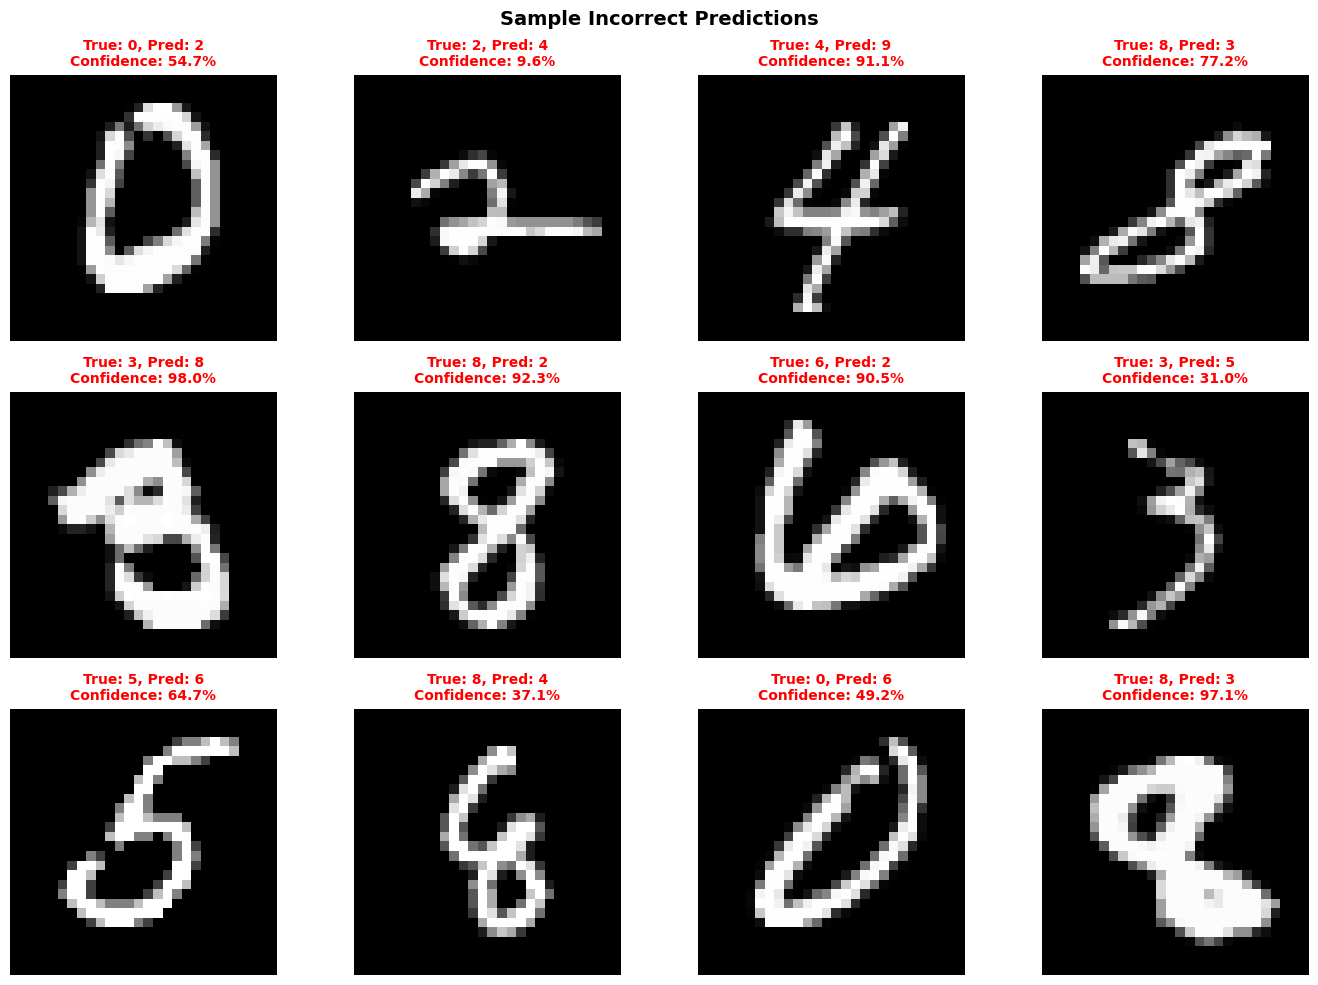

In [24]:
# Visualize incorrect predictions (if any)
incorrect_indices = np.where(predictions != true_labels)[0]

if len(incorrect_indices) > 0:
    print("Visualizing incorrect predictions...")
    incorrect_sample_indices = np.random.choice(incorrect_indices, min(12, len(incorrect_indices)), replace=False)
    
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    fig.suptitle('Sample Incorrect Predictions', fontsize=14, fontweight='bold')
    
    for idx, img_idx in enumerate(incorrect_sample_indices):
        ax = axes[idx // 4, idx % 4]
        x, y = test_data[img_idx]
        image = x.reshape(28, 28)
        
        # Get network output for confidence
        output = net.feedforward(x)
        confidence = np.max(output)
        
        ax.imshow(image, cmap='gray')
        ax.set_title(f'True: {true_labels[img_idx]}, Pred: {predictions[img_idx]}\nConfidence: {confidence*100:.1f}%', 
                     fontsize=10, color='red', fontweight='bold')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Perfect accuracy! No incorrect predictions to display.")

## 8. Analyze Network Confidence

Visualize the distribution of confidence scores:


Confidence Statistics:
  Mean confidence (all): 0.9645
  Mean confidence (correct): 0.9778
  Mean confidence (incorrect): 0.6916


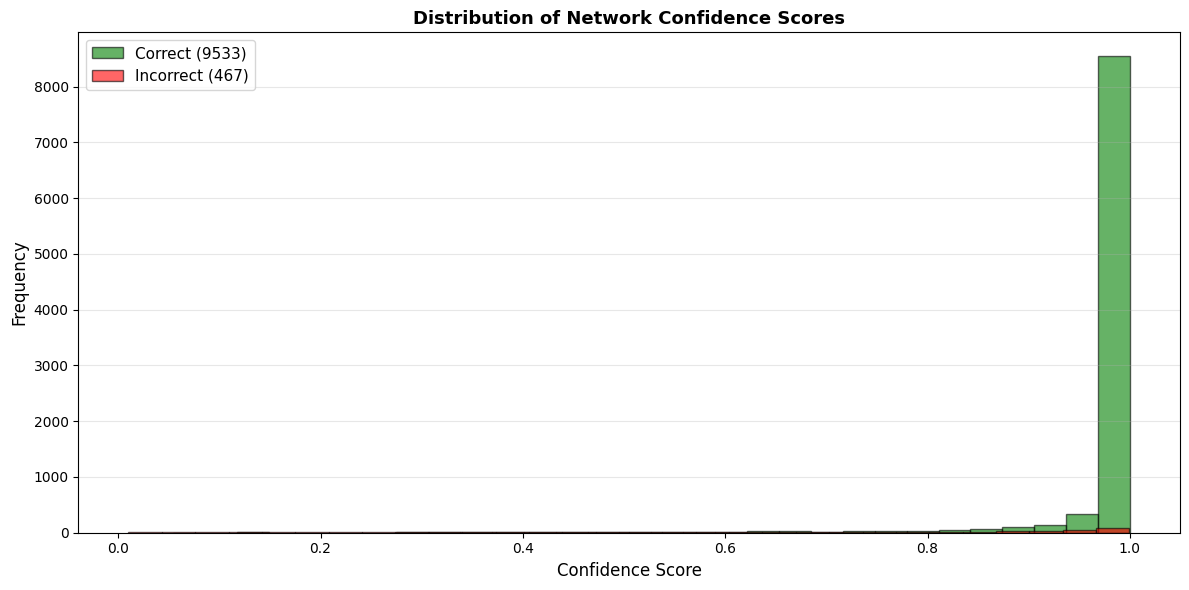

In [25]:
# Calculate confidence scores for all predictions
confidences_all = []
confidences_correct = []
confidences_incorrect = []

for i, (x, y) in enumerate(test_data):
    output = net.feedforward(x)
    confidence = np.max(output)
    confidences_all.append(confidence)
    
    if predictions[i] == true_labels[i]:
        confidences_correct.append(confidence)
    else:
        confidences_incorrect.append(confidence)

confidences_all = np.array(confidences_all)
confidences_correct = np.array(confidences_correct)
confidences_incorrect = np.array(confidences_incorrect)

# Plot confidence distribution
fig, ax = plt.subplots(figsize=(12, 6))

if len(confidences_incorrect) > 0:
    ax.hist(confidences_correct, bins=30, alpha=0.6, label=f'Correct ({len(confidences_correct)})', color='green', edgecolor='black')
    ax.hist(confidences_incorrect, bins=30, alpha=0.6, label=f'Incorrect ({len(confidences_incorrect)})', color='red', edgecolor='black')
else:
    ax.hist(confidences_all, bins=30, alpha=0.7, label='All Predictions', color='blue', edgecolor='black')

ax.set_xlabel('Confidence Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Network Confidence Scores', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

print(f"\nConfidence Statistics:")
print(f"  Mean confidence (all): {np.mean(confidences_all):.4f}")
print(f"  Mean confidence (correct): {np.mean(confidences_correct):.4f}")
if len(confidences_incorrect) > 0:
    print(f"  Mean confidence (incorrect): {np.mean(confidences_incorrect):.4f}")

plt.tight_layout()
plt.show()